# **Section 1: Load Data**

In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
patient_df = pd.read_csv('patient_journey.csv')

# **Section 2: Patient Segmentation by Engagement**
2.1 Engagement Categories

In [3]:
patient_df['engagement_segment'] = pd.qcut(
    patient_df['engagement_score'],
    q=3,
    labels=[
        'Low Engagement',
        'Medium Engagement',
        'High Engagement'
    ]
)
patient_df[
    ['engagement_score',
     'engagement_segment']
].head()

,engagement_score,engagement_segment
0,52.5,Medium Engagement
1,75.7,High Engagement
2,78.5,High Engagement
3,56.0,Medium Engagement
4,47.3,Medium Engagement


2.2 Segment Distribution

In [4]:
patient_df[
    'engagement_segment'
].value_counts()

,count
engagement_segment,
Low Engagement,501
Medium Engagement,500
High Engagement,499


2.3 Visualization

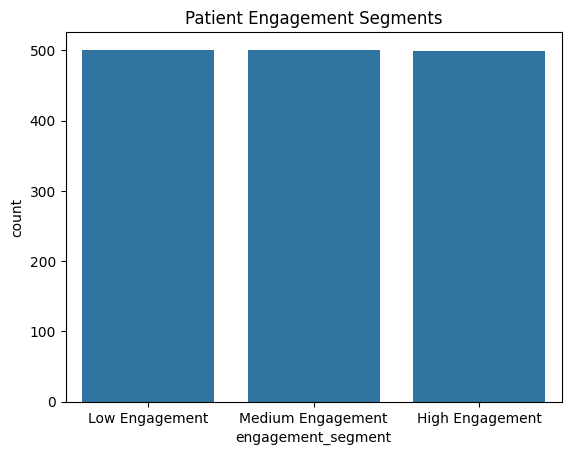

In [5]:
sns.countplot(
    data=patient_df,
    x='engagement_segment'
)
plt.title(
    'Patient Engagement Segments'
)
plt.show()

# **Section 3: Conversion-Based Segmentation**
3.1 Conversion Segments

In [6]:
patient_df[
    'conversion_segment'
] = np.where(
    patient_df[
        'treatment_completed'
    ] == 1,
    'Converted',
    'Not Converted'
)

3.2 Segment Counts

In [7]:
patient_df[
    'conversion_segment'
].value_counts()

,count
conversion_segment,
Not Converted,946
Converted,554


3.3 Visualization

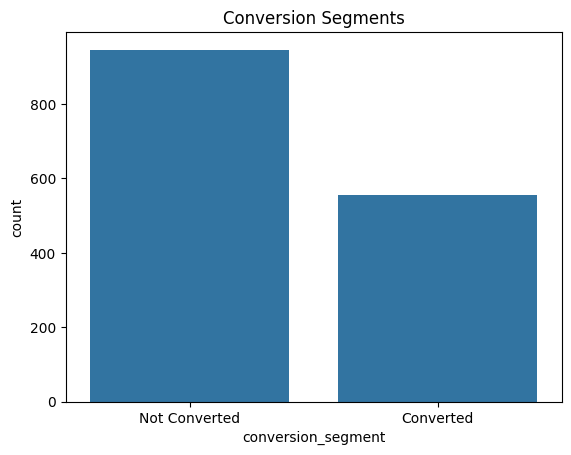

In [8]:
sns.countplot(
    data=patient_df,
    x='conversion_segment'
)
plt.title(
    'Conversion Segments'
)
plt.show()

# **Section 4: Country Segmentation**
4.1 Country Performance

In [9]:
country_segment = (
    patient_df.groupby('country')
    ['treatment_completed']
    .mean()
    .reset_index()
)
country_segment[
    'conversion_rate'
] = (
    country_segment[
        'treatment_completed'
    ] * 100
)
display(country_segment)

,country,treatment_completed,conversion_rate
0,Bangladesh,0.375000,37.500000
1,India,0.361702,36.170213
2,Kenya,0.444444,44.444444
3,Malaysia,0.415385,41.538462
4,Nepal,0.353383,35.338346
5,Nigeria,0.282051,28.205128
6,Oman,0.376923,37.692308
7,Philippines,0.368794,36.879433
8,Sri Lanka,0.353448,35.344828
9,Tanzania,0.341667,34.166667


4.2 High vs Low Performing Countries

In [10]:
country_segment[
    'country_segment'
] = np.where(
    country_segment[
        'conversion_rate'
    ] >=
    country_segment[
        'conversion_rate'
    ].median(),
    'High Performing',
    'Low Performing'
)
display(country_segment)

,country,treatment_completed,conversion_rate,country_segment
0,Bangladesh,0.375000,37.500000,High Performing
1,India,0.361702,36.170213,Low Performing
2,Kenya,0.444444,44.444444,High Performing
3,Malaysia,0.415385,41.538462,High Performing
4,Nepal,0.353383,35.338346,Low Performing
5,Nigeria,0.282051,28.205128,Low Performing
6,Oman,0.376923,37.692308,High Performing
7,Philippines,0.368794,36.879433,High Performing
8,Sri Lanka,0.353448,35.344828,Low Performing
9,Tanzania,0.341667,34.166667,Low Performing


# **Section 5: Provider Segmentation**
5.1 Provider Performance

In [11]:
provider_segment = (
    patient_df.groupby('provider_id')
    ['treatment_completed']
    .mean()
    .reset_index()
)
provider_segment[
    'conversion_rate'
] = (
    provider_segment[
        'treatment_completed'
    ] * 100
)
display(provider_segment)

,provider_id,treatment_completed,conversion_rate
0,PVD-001,0.472727,47.272727
1,PVD-002,0.404762,40.476190
2,PVD-003,0.440678,44.067797
3,PVD-004,0.363636,36.363636
4,PVD-005,0.270833,27.083333
5,PVD-006,0.272727,27.272727
6,PVD-007,0.520000,52.000000
7,PVD-008,0.509091,50.909091
8,PVD-009,0.392857,39.285714
9,PVD-010,0.365854,36.585366


5.2 Provider Category

In [12]:
provider_segment[
    'provider_segment'
] = np.where(
    provider_segment[
        'conversion_rate'
    ] >=
    provider_segment[
        'conversion_rate'
    ].median(),
    'Top Provider',
    'Needs Improvement'
)
display(provider_segment)

,provider_id,treatment_completed,conversion_rate,provider_segment
0,PVD-001,0.472727,47.272727,Top Provider
1,PVD-002,0.404762,40.476190,Top Provider
2,PVD-003,0.440678,44.067797,Top Provider
3,PVD-004,0.363636,36.363636,Needs Improvement
4,PVD-005,0.270833,27.083333,Needs Improvement
5,PVD-006,0.272727,27.272727,Needs Improvement
6,PVD-007,0.520000,52.000000,Top Provider
7,PVD-008,0.509091,50.909091,Top Provider
8,PVD-009,0.392857,39.285714,Top Provider
9,PVD-010,0.365854,36.585366,Top Provider


# **Section 6: High-Risk Patient Identification**
6.1 Risk Rules

In [13]:
patient_df['risk_segment'] = np.where(
    (
        patient_df[
            'response_time_hours'
        ] > 24
    )
    &
    (
        patient_df[
            'engagement_score'
        ] < 50
    ),
    'High Risk',
    'Normal Risk'
)

6.2 Risk Distribution

In [14]:
patient_df[
    'risk_segment'
].value_counts()

,count
risk_segment,
Normal Risk,1310
High Risk,190


6.3 Visualization

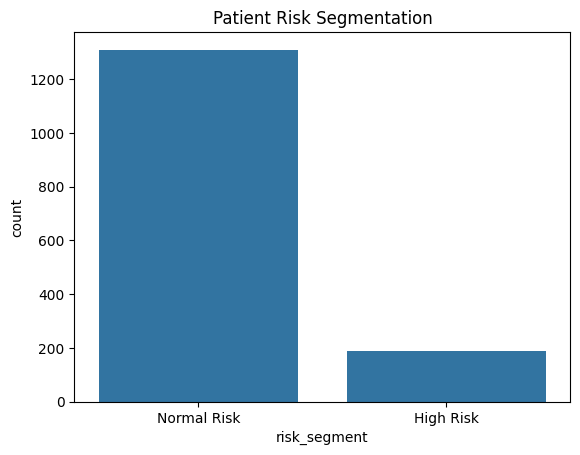

In [15]:
sns.countplot(
    data=patient_df,
    x='risk_segment'
)
plt.title(
    'Patient Risk Segmentation'
)
plt.show()

# **Section 7: Recommendation Engine**
7.1 Generate Recommendations

In [16]:
def generate_recommendation(row):
    if row['risk_segment'] == 'High Risk':
        return 'Immediate Follow-up'
    elif row['engagement_segment'] == 'Low Engagement':
        return 'Increase Engagement'
    elif row['conversion_segment'] == 'Converted':
        return 'Retention Campaign'
    else:
        return 'Standard Follow-up'

7.2 Apply Recommendations

In [17]:
patient_df[
    'recommendation'
] = patient_df.apply(
    generate_recommendation,
    axis=1
)
display(
    patient_df[
        [
            'patient_id',
            'recommendation'
        ]
    ].head()
)

,patient_id,recommendation
0,MTE-PAT-00001,Standard Follow-up
1,MTE-PAT-00002,Retention Campaign
2,MTE-PAT-00003,Retention Campaign
3,MTE-PAT-00004,Standard Follow-up
4,MTE-PAT-00005,Standard Follow-up


7.3 Recommendation Summary

In [18]:
patient_df[
    'recommendation'
].value_counts()

,count
recommendation,
Retention Campaign,486
Standard Follow-up,475
Increase Engagement,349
Immediate Follow-up,190


7.4 Visualization

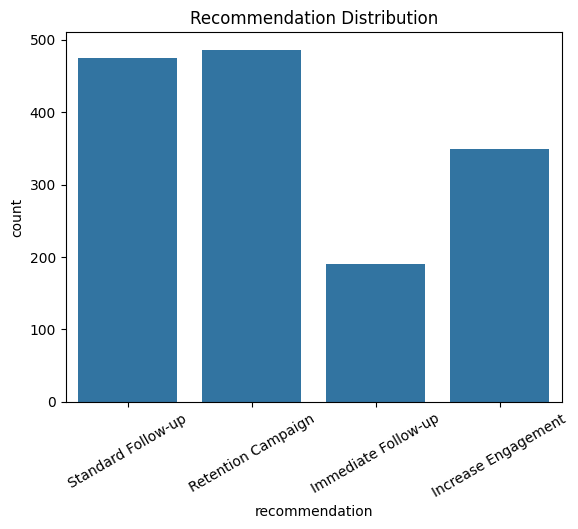

In [19]:
sns.countplot(
    data=patient_df,
    x='recommendation'
)
plt.xticks(rotation=30)

plt.title(
    'Recommendation Distribution'
)
plt.show()

# **Section 8: Executive Summary**
KPI Summary

In [20]:
summary = pd.DataFrame({
    'Metric':[
        'Total Patients',
        'Converted Patients',
        'High Risk Patients'
    ],
    'Value':[
        len(patient_df),
        patient_df[
            'treatment_completed'
        ].sum(),
        (
            patient_df[
                'risk_segment'
            ]
            ==
            'High Risk'
        ).sum()
    ]
})
display(summary)

,Metric,Value
0,Total Patients,1500
1,Converted Patients,554
2,High Risk Patients,190


# **Segmentation & Recommendations Summary**

## Segments Created

- Engagement Segments
- Value Segments
- Conversion Segments
- Country Segments
- Provider Segments
- Risk Segments

## Recommendations

- Prioritize High Risk Patients
- Improve Response Time
- Increase Engagement for Low Activity Patients
- Focus on High Value Markets
- Replicate Best Provider Practices

## Business Impact

- Better Patient Retention
- Improved Conversion Rates
- Higher Revenue Potential
- Efficient Resource Allocation